# Generalised elliptical model

In [38]:
import numpy as np
import dill

from matplotlib import pyplot as plt

# Use TeX
from matplotlib import rc
rc('font', size=18)
rc('text', usetex=True)
rc('font', family='serif')

from matplotlib.patches import Ellipse, Circle

from scipy.optimize import fsolve
from scipy.differentiate import derivative, jacobian

import time

# 1. Define the ellipse fields

We use here the following expressions of the ellipticity $e(\zeta)$, pointing angle $\phi(\zeta)$, and central position $\boldsymbol{x}_{\rm c}(\zeta)$ as a function of elliptical radius $\zeta$, inspired from the analysis of the isopotential contours of COLIBRE lenses:
$$
e(\zeta) = e_\infty + (e_0-e_\infty) \exp\left(-\frac{\zeta}{\Delta \zeta_e}\right)
$$
$$
\phi(\zeta) = \phi_0 + \frac{4\Delta\phi}{\pi} \arctan\left(\frac{\zeta - \zeta_0}{\Delta \zeta_\phi}\right)
$$
$$
x_{\rm c}(\zeta) = d_x \zeta \qquad
y_{\rm c}(\zeta) = d_y \zeta
$$

In [2]:
def ellipse_fields(zeta, e_inf, e_0, Dzeta_e, phi_0, Dphi, zeta_0, Dzeta_phi, drift_x, drift_y):
    """
    Calculates the ellipticity, pointing angle and central position of the ellipse
    with elliptical radius zeta, as well as their derivatives with respect to zeta.
    """

    e    = e_inf + (e_0 - e_inf) * np.exp(-zeta / Dzeta_e)
    e_z  = - (e_0 - e_inf) / Dzeta_e * np.exp(-zeta / Dzeta_e)
    e_zz = - e_z / Dzeta_e
    
    phi    = phi_0 + 4 * Dphi / np.pi * np.arctan((zeta - zeta_0) / Dzeta_phi)
    phi_z  = 4 * Dphi / np.pi / Dzeta_phi / (1 + (zeta - zeta_0)**2 / Dzeta_phi**2)
    phi_zz = - np.pi * (zeta - zeta_0) * phi_z**2 / 2 / Dphi / Dzeta_phi
    
    
    xc    = drift_x * zeta
    xc_z  = drift_x
    xc_zz = 0
    
    yc    = drift_y * zeta
    yc_z  = drift_y
    yc_zz = 0

    return (e, phi, xc, yc), (e_z, phi_z, xc_z, yc_z), (e_zz, phi_zz, xc_zz, yc_zz)

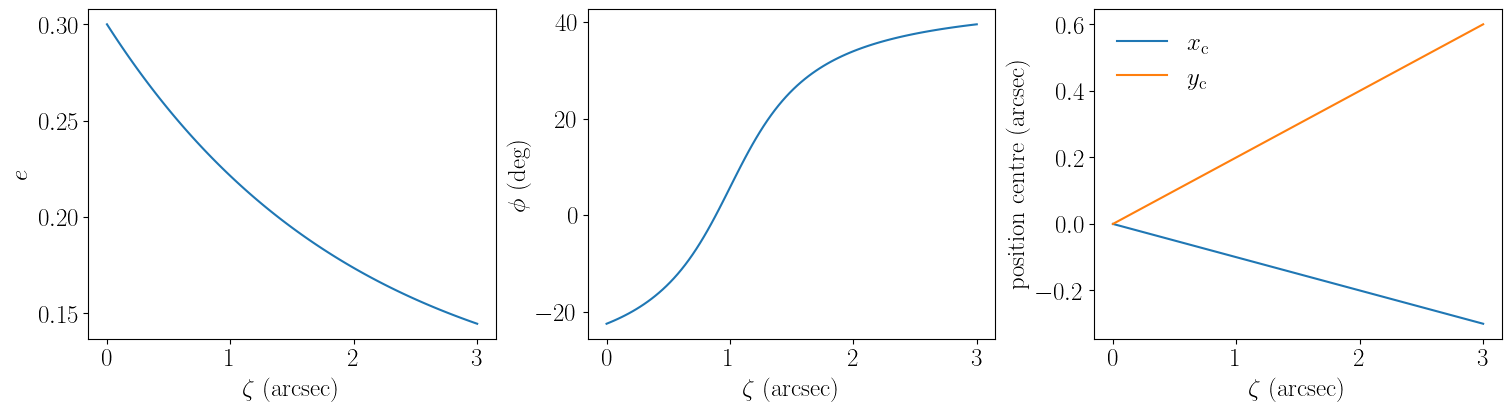

In [3]:
params_ellipticity = {'e_inf': 0.1 , 'e_0': 0.3, 'Dzeta_e': 2}
params_pointing_angle = {'phi_0': 0.1, 'Dphi': 20 * np.pi / 180, 'zeta_0': 1, 'Dzeta_phi': 0.5}
params_centre = {'drift_x': -0.1, 'drift_y': 0.2}
params_ellipses = params_ellipticity | params_pointing_angle | params_centre

zeta = np.linspace(0, 3, 100) # elliptical radius in arcsec
(e, phi, xc, yc), _, _ = ellipse_fields(zeta, **params_ellipses)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')

ax=axes[0]
ax.plot(zeta, e)
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r'$e$')

ax=axes[1]
ax.plot(zeta, phi * 180 / np.pi)
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r'$\phi$ (deg)')

ax=axes[2]
ax.plot(zeta, xc, label=r'$x_{\rm c}$')
ax.plot(zeta, yc, label=r'$y_{\rm c}$')
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r'position centre (arcsec)')
ax.legend(frameon=False)

plt.show();

# 2. Determine the elliptical radius

The elliptical radius $\zeta(\boldsymbol{x})$ is the solution of $\zeta = F(\zeta; \boldsymbol{x})$, with
$$
F^2(\zeta;\boldsymbol{x})
= [\boldsymbol{X} - \boldsymbol{X}_{\rm c}(\zeta)]^T \boldsymbol{E}(\zeta) [\boldsymbol{X} - \boldsymbol{X}_{\rm c}(\zeta)]
$$
and
$$
\boldsymbol{E}
= \sqrt{1+e^2}\,\boldsymbol{1}_2
-
\begin{bmatrix}
e_1 & e_2 \\
e_2 & -e_1
\end{bmatrix}
=
\begin{bmatrix}
\cos\phi & -\sin\phi \\
\sin\phi & \cos\phi
\end{bmatrix}
\begin{bmatrix}
q & 0 \\
0 & 1/q
\end{bmatrix}
\begin{bmatrix}
\cos\phi & \sin\phi \\
-\sin\phi & \cos\phi
\end{bmatrix}
$$
if $(e_1, e_2)=e(\cos 2\phi, \sin2\phi)$.

I use an iterative perturbative method using a quadratic expansion of the function $F$ above to solve it numerically in an efficient way. The use of a quadratic method is motivated by the fact that we must compute the second derivatives of the various fields to get the Hessian matrix anyway.

The method consists in starting from an approximation $\zeta_0=\sqrt{x^2+y^2}$ of the solution, and then
$$
\zeta = \zeta_0 + \zeta_1 + \zeta_2 = F(\zeta_0) + (\zeta_1+\zeta_2) F'(\zeta_0) + \frac{1}{2} \, \zeta_1^2 F''(\zeta_1) \ ,
$$
where a prime denotes a partial derivative with respect to $\zeta$, i.e. $F'(\boldsymbol{x})\equiv \partial F/\partial\zeta$. We find
$$
\zeta_1 = \frac{F(\zeta_0)-\zeta_0}{1 - F'(\zeta_0)}
\qquad
\zeta_2 = \frac{F''(\zeta_0)}{1-F'(\zeta_0)} \, \zeta_1^2 \ .
$$

## Properties of function $F$

The key is to compute $F$ and its derivatives. Denoting $\boldsymbol{X}_1=\boldsymbol{X}-\boldsymbol{X}_{\rm c}$, we have
$$
F'
= F^{-1}
\left[
\frac{1}{2} \boldsymbol{X}_1^T \boldsymbol{E}' \boldsymbol{X}_1 - (\boldsymbol{X}_{\rm c}')^T \boldsymbol{E}\boldsymbol{X}_1
\right]
$$
with the first derivative
$$
\boldsymbol{E}' = e' \partial_e \boldsymbol{E} + \phi' \partial_\phi \boldsymbol{E}
\qquad
\partial_e \boldsymbol{E} 
=
\frac{e}{\sqrt{1+e^2}} \, \boldsymbol{1}_2
-
\begin{bmatrix}
\cos 2\phi & \sin 2\phi \\
\sin 2\phi & -\cos 2\phi
\end{bmatrix}
\qquad
\partial_\phi \boldsymbol{E} 
=
2
\begin{bmatrix}
e_2 & -e_1 \\
-e_1 & -e_2
\end{bmatrix}
$$
and the second derivative
$$
F''
= F^{-1}
\left[
- (\boldsymbol{X}_{\rm c}'')^T \boldsymbol{E}\boldsymbol{X}_1
- 2(\boldsymbol{X}_{\rm c}')^T \boldsymbol{E}'\boldsymbol{X}_1
+ (\boldsymbol{X}_{\rm c}')^T \boldsymbol{E}\boldsymbol{X}'_{\rm c}
+ \frac{1}{2} \boldsymbol{X}_1^T \boldsymbol{E}'' \boldsymbol{X}_1
- (F')^2
\right]
$$
with
$$
\boldsymbol{E}''
= e'' \partial_e\boldsymbol{E} + (e')^2 \partial^2_e\boldsymbol{E} + 2e'\phi' \partial_e\partial_\phi\boldsymbol{E}
+ \phi'' \partial_\phi\boldsymbol{E} + (\phi')^2\partial^2_\phi\boldsymbol{E}
$$
and
$$
\partial_e^2\boldsymbol{E} = [(1+e^2)^{-1/2} - e(1+e^2)^{-3/2}]\boldsymbol{1}_2
\qquad
\partial_e\partial\phi\boldsymbol{E}
= 2
\begin{bmatrix}
\sin 2\phi & -\cos 2\phi \\
-\cos 2\phi & -\sin 2\phi
\end{bmatrix}
\qquad
\partial_\phi^2\boldsymbol{E} =
4
\begin{bmatrix}
e_1 & e_2 \\
e_2 & -e_1
\end{bmatrix}
$$

In [9]:
def elliptical_radius_function(x, y, zeta, **params):
    """
    Define F such that zeta = F(zeta; x, y)
    Returns F and its first and second derivatives with respect to zeta, x and y
    """

    # properties of the ellipse at zeta
    
    (e, phi, xc, yc), (e_z, phi_z, xc_z, yc_z), (e_zz, phi_zz, xc_zz, yc_zz) = ellipse_fields(zeta, **params)

    
    # F
    
    x1 = x - xc
    y1 = y - yc

    c2 = np.cos(2*phi)
    s2 = np.sin(2*phi)

    e1 = e * c2
    e2 = e * s2
    
    E_xx = (1 + e**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e**2)**0.5 + e1

    EX1_x = E_xx * x1 + E_xy * y1
    EX1_y = E_yx * x1 + E_yy * y1
        
    F2 = EX1_x * x1 + EX1_y * y1
    F = F2**0.5

    
    # dF / d zeta

    # E'
    E_xx_e = e / (1 + e**2)**0.5 - np.cos(2*phi)
    E_xy_e = - np.sin(2*phi)
    E_yx_e = E_xy_e
    E_yy_e = e / (1 + e**2)**0.5 + np.cos(2*phi)

    E_xx_phi = 2 * e2
    E_xy_phi = - 2 * e1
    E_yx_phi = E_xy_phi
    E_yy_phi = - 2 * e2

    E_xx_z = e_z * E_xx_e + phi_z * E_xx_phi
    E_xy_z = e_z * E_xy_e + phi_z * E_xy_phi
    E_yx_z = E_xy_z
    E_yy_z = e_z * E_yy_e + phi_z * E_yy_phi

    # E' X1
    E_zX1_x = (E_xx_z * x1 + E_xy_z * y1)
    E_zX1_y = (E_yx_z * x1 + E_yy_z * y1)

    # E Xc'
    EXc_z_x = E_xx * xc_z + E_xy * yc_z
    EXc_z_y = E_yx * xc_z + E_yy * yc_z

    # Xc' E X1
    Xc_zEX1 = xc_z * EX1_x + yc_z * EX1_y

    # X1 E' X1
    X1E_zX1 = x1 * E_zX1_x + y1 * E_zX1_y
    
    F_z = (X1E_zX1 / 2 - Xc_zEX1) / F


    # Spatial gradients

    F_x = EX1_x / F
    F_y = EX1_y / F
    
    
    # d^2F / d zeta^2

    # E''
    E_xx_ee = (1 + e**2)**(-0.5) - e * (1 + e**2)**(-1.5)
    E_xy_ee = 0
    E_yx_ee = 0
    E_yy_ee = E_xx_ee

    E_xx_ephi = 2 * s2
    E_xy_ephi = - 2 * c2
    E_yx_ephi = E_xy_ephi
    E_yy_ephi = - 2 * s2

    E_xx_phiphi = 4 * e1
    E_xy_phiphi = 4 * e2
    E_yx_phiphi = E_xy_phiphi
    E_yy_phiphi = - 4 * e1
    
    E_xx_zz = e_zz * E_xx_e + e_z**2 * E_xx_ee + 2 * e_z * phi_z * E_xx_ephi + phi_zz * E_xx_phi + phi_z**2 * E_xx_phiphi
    E_xy_zz = e_zz * E_xy_e + e_z**2 * E_xy_ee + 2 * e_z * phi_z * E_xy_ephi + phi_zz * E_xy_phi + phi_z**2 * E_xy_phiphi
    E_yx_zz = E_xy_zz
    E_yy_zz = e_zz * E_yy_e + e_z**2 * E_yy_ee + 2 * e_z * phi_z * E_yy_ephi + phi_zz * E_yy_phi + phi_z**2 * E_yy_phiphi

    # E'' X1
    E_zzX1_x = E_xx_zz * x1 + E_xy_zz * y1
    E_zzX1_y = E_yx_zz * x1 + E_yy_zz * y1
    
    Xc_zzEX1  = xc_zz * EX1_x  + yc_zz * EX1_y
    Xc_zE_zX1 = xc_z * E_zX1_x + yc_z * E_zX1_y
    Xc_zEXc_z = xc_z * EXc_z_x + yc_z * EXc_z_y
    X1E_zzX1  = x1 * E_zzX1_x  + y1 * E_zzX1_y
    
    F_zz = (-Xc_zzEX1 - 2 * Xc_zE_zX1 + Xc_zEXc_z + 0.5 * X1E_zzX1 - F_z**2) / F

    
    # rest of the Hessian

    F_xx = (E_xx - F_x * F_x) / F
    F_xy = (E_xy - F_x * F_y) / F
    F_yy = (E_yy - F_y * F_y) / F
    
    F_xz = (E_zX1_x -  EXc_z_x - F_x * F_z) / F
    F_yz = (E_zX1_y -  EXc_z_y - F_y * F_z) / F

    
    return F, (F_x, F_y, F_z), (F_xx, F_xy, F_xz, F_yy, F_yz, F_zz)

Check that the derivatives are consistent

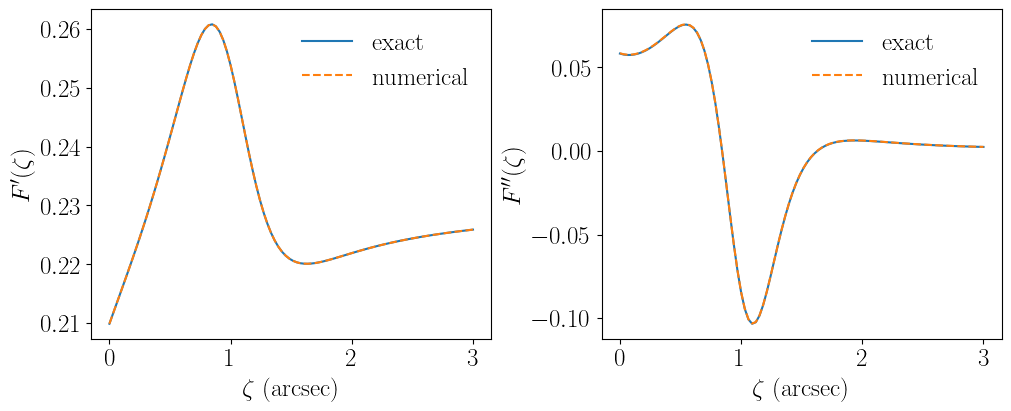

In [10]:
zeta = np.linspace(0, 3, 100)
x = 2 * np.random.rand() - 1
y = 2 * np.random.rand() - 1
F, (_, _, F_z), (_, _, _, _, _, F_zz) = elliptical_radius_function(x, y, zeta, **params_ellipses)

# compute F_z numerically
func = lambda zeta: elliptical_radius_function(x, y, zeta, **params_ellipses)[0]
res = derivative(func, zeta)
F_z_num = res.df

# compute F_zz numerically
func = lambda zeta: elliptical_radius_function(x, y, zeta, **params_ellipses)[1][2]
res = derivative(func, zeta)
F_zz_num = res.df

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')

ax=axes[0]
ax.plot(zeta, F_z, label='exact')
ax.plot(zeta, F_z_num, '--', label='numerical')
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r"$F'(\zeta)$")
ax.legend(frameon=False)

ax=axes[1]
ax.plot(zeta, F_zz, label='exact')
ax.plot(zeta, F_zz_num, '--', label='numerical')
ax.set_xlabel(r'$\zeta$ (arcsec)')
ax.set_ylabel(r"$F''(\zeta)$")
ax.legend(frameon=False)

plt.show();

## Solving for $\zeta$

In [11]:
def get_elliptical_radius(x, y, N_iter=3, **params):
    """
    Iteratively solve zeta = F(x, zeta) for zeta.
    """
    
    zeta = (x**2 + y**2)**0.5 # first guess
    
    # get zeta iteratively
    for i in range(N_iter):

        F, (F_x, F_y, F_z), (F_xx, F_xy, F_xz, F_yy, F_yz, F_zz) = elliptical_radius_function(x, y, zeta, **params)
        
        zeta1 = (F - zeta) / (1 - F_z)
        zeta2 = F_zz / 2 / (1 - F_z) * zeta1**2
        zeta += zeta1 + zeta2

    # gradient of zeta
    zeta_x = F_x / (1 - F_z)
    zeta_y = F_y / (1 - F_z)

    # Hessian of zeta
    zeta_xx = (F_xx + F_xz * zeta_x + F_xz * zeta_x + F_zz * zeta_x * zeta_x) / (1 - F_z)
    zeta_xy = (F_xy + F_xz * zeta_y + F_yz * zeta_x + F_zz * zeta_x * zeta_y) / (1 - F_z)
    zeta_yy = (F_yy + F_yz * zeta_y + F_yz * zeta_y + F_zz * zeta_y * zeta_y) / (1 - F_z)
        
    return zeta, (zeta_x, zeta_y), (zeta_xx, zeta_xy, zeta_yy)

Check that it works

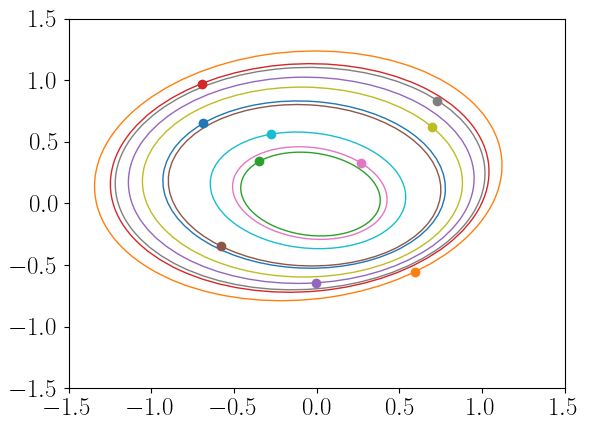

In [12]:
# generate a set of N random points in [-1, 1]^2
N = 10
x = 2 * np.random.random_sample(N) - 1
y = 2 * np.random.random_sample(N) - 1

# get the corresponding elliptical radii
zetas = get_elliptical_radius(x, y, N_iter=3, **params_ellipses)[0]

# plot the points and the ellipses
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots()

for i, zeta in enumerate(zetas):

    (e, phi, x0, y0), _, _ = ellipse_fields(zeta, **params_ellipses)
    q = (1 + e**2)**0.5 - e
    a = zeta / q**0.5
    b = zeta * q**0.5

    colour = colours[i% len(colours)]
    
    ellipse = Ellipse(
    xy=(x0, y0),
    width=2*a,
    height=2*b,
    angle=phi * 180 / np.pi,
    facecolor="none",
    edgecolor=colour
    )
    
    ax.plot(x[i], y[i], 'o', color=colour)
    ax.add_artist(ellipse)

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.show()

Convergence as a function of the number of iterations

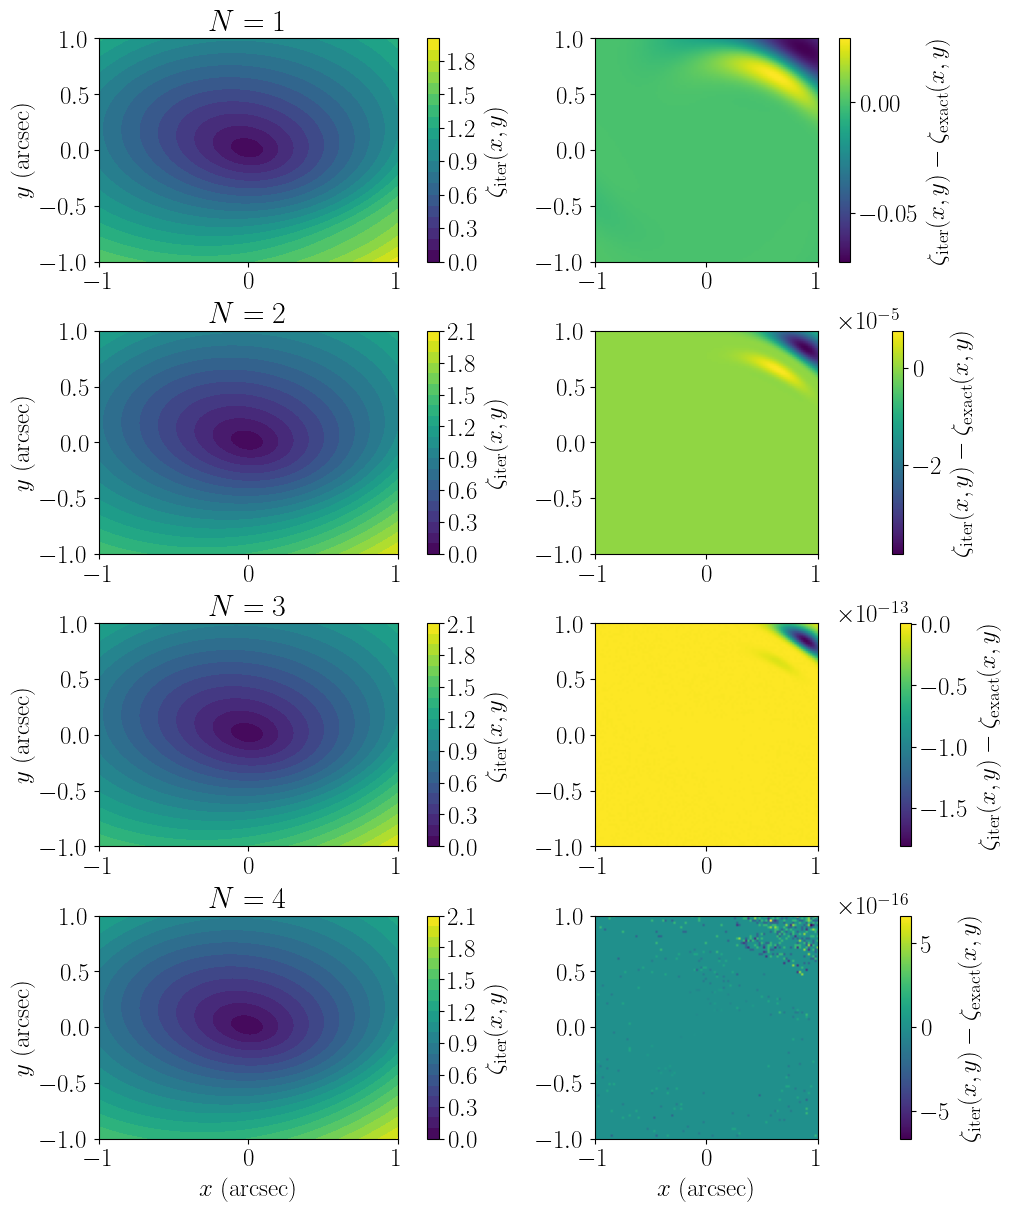

In [13]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)

N_iters = [1, 2, 3, 4]
zeta_exact = get_elliptical_radius(X, Y, 10, **params_ellipses)[0]

fig, axes = plt.subplots(len(N_iters), 2, figsize=(10, 3*len(N_iters)), layout="constrained")

for i, N_iter in enumerate(N_iters):

    zeta = get_elliptical_radius(X, Y, N_iter, **params_ellipses)[0]
    diff = zeta - zeta_exact

    #ax = axes[i, 0]
    #contours = ax.contourf(X, Y, zeta_exact, levels=20)
    #fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm exact}(x, y)$')

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta, levels=20)
    fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm iter}(x, y)$')
    ax.set_title(r"$N = {}$".format(N_iter))

    ax = axes[i, 1]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=r'$\zeta_{\rm iter}(x, y) - \zeta_{\rm exact}(x, y)$')

for i in range(len(N_iters)):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(2):
    axes[len(N_iters)-1, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

In [14]:
for N_iter in N_iters:

    start = time.perf_counter()
    get_elliptical_radius(X, Y, N_iter, **params_ellipses)
    end = time.perf_counter()
    timing = 1000 * (end - start) # ms
    print("Time for {} iteration(s) = {} ms".format(N_iter, timing))

Time for 1 iteration(s) = 2.960694022476673 ms
Time for 2 iteration(s) = 4.4272528029978275 ms
Time for 3 iteration(s) = 7.386962883174419 ms
Time for 4 iteration(s) = 10.338138788938522 ms


## Gradient of $\zeta$

In [15]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)

# calculation from iterative method
_, (zeta_x, zeta_y), _ = get_elliptical_radius(X, Y, N_iter=3, **params_ellipses)


# calculation from numerical differentiation

zeta_exact = lambda x, y: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[0]
res = derivative(zeta_exact, X, args=(Y,))
zeta_x_num = res.df

zeta_exact = lambda y, x: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[0]
res = derivative(zeta_exact, Y, args=(X,))
zeta_y_num = res.df

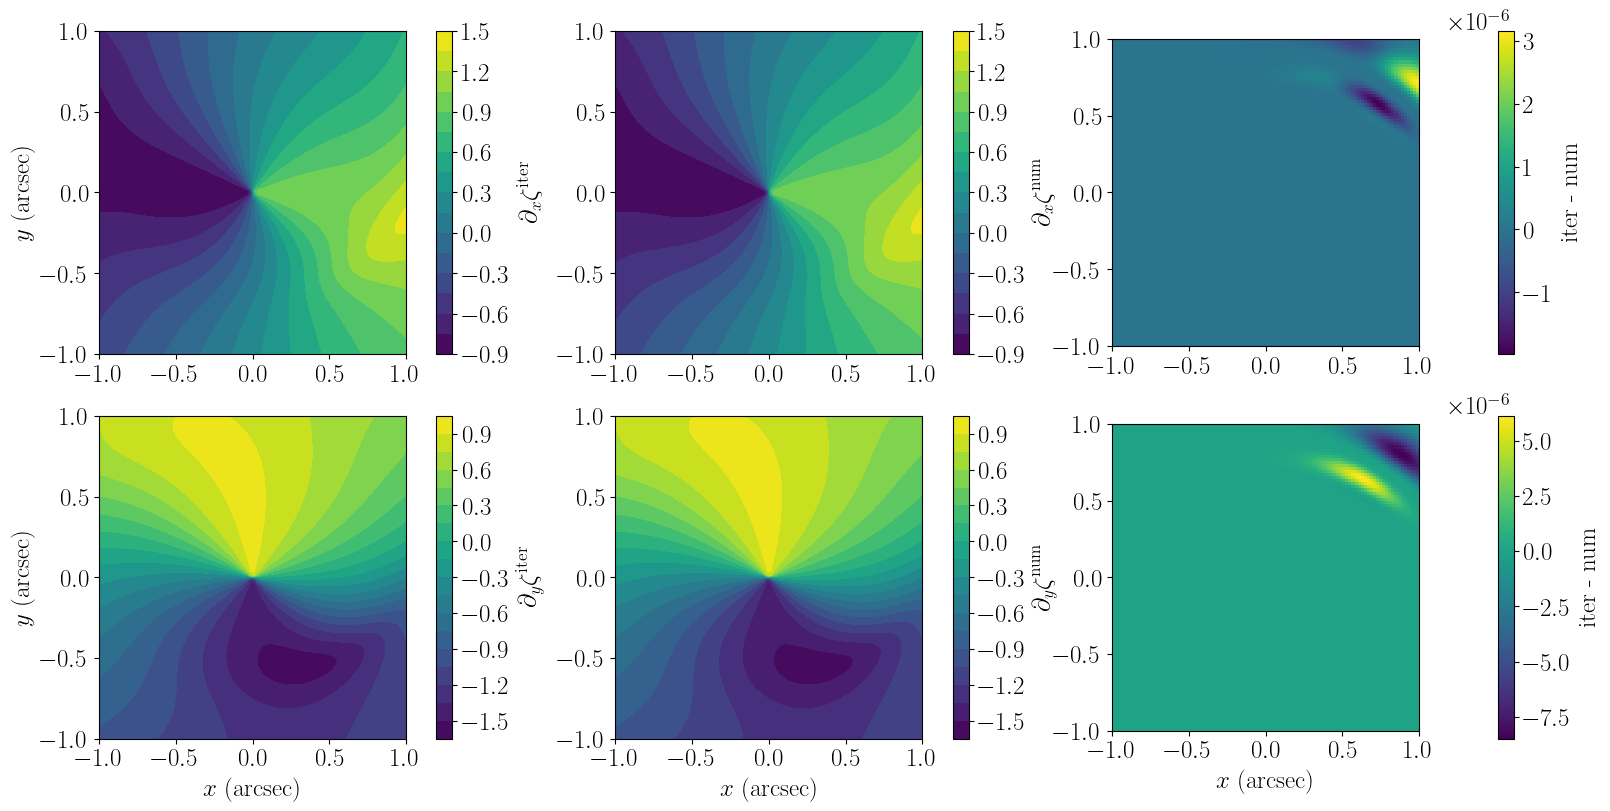

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 4*2), layout="constrained")

grad_zeta_num = [zeta_x_num, zeta_y_num]
labels = [[r'$\partial_x\zeta^{\rm iter}$', r'$\partial_x\zeta^{\rm num}$', r'iter - num'],
          [r'$\partial_y\zeta^{\rm iter}$', r'$\partial_y\zeta^{\rm num}$', r'iter - num']]

for i, zeta_i in enumerate([zeta_x, zeta_y]):

    zeta_i_num = grad_zeta_num[i]
    diff = zeta_i - zeta_i_num

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta_i, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][0])

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, zeta_i_num, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][1])

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=labels[i][2])

for i in range(2):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[1, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

## Hessian of $\zeta$

In [17]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)

# calculation from iterative method
_, _, (zeta_xx, zeta_xy, zeta_yy) = get_elliptical_radius(X, Y, N_iter=3, **params_ellipses)

zeta_x = lambda x, y: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[1][0]
res = derivative(zeta_x, X, args=(Y,))
zeta_xx_num = res.df

zeta_x = lambda y, x: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[1][0]
res = derivative(zeta_x, Y, args=(X,))
zeta_xy_num = res.df

zeta_y = lambda y, x: get_elliptical_radius(x, y, N_iter=10, **params_ellipses)[1][1]
res = derivative(zeta_y, Y, args=(X,))
zeta_yy_num = res.df

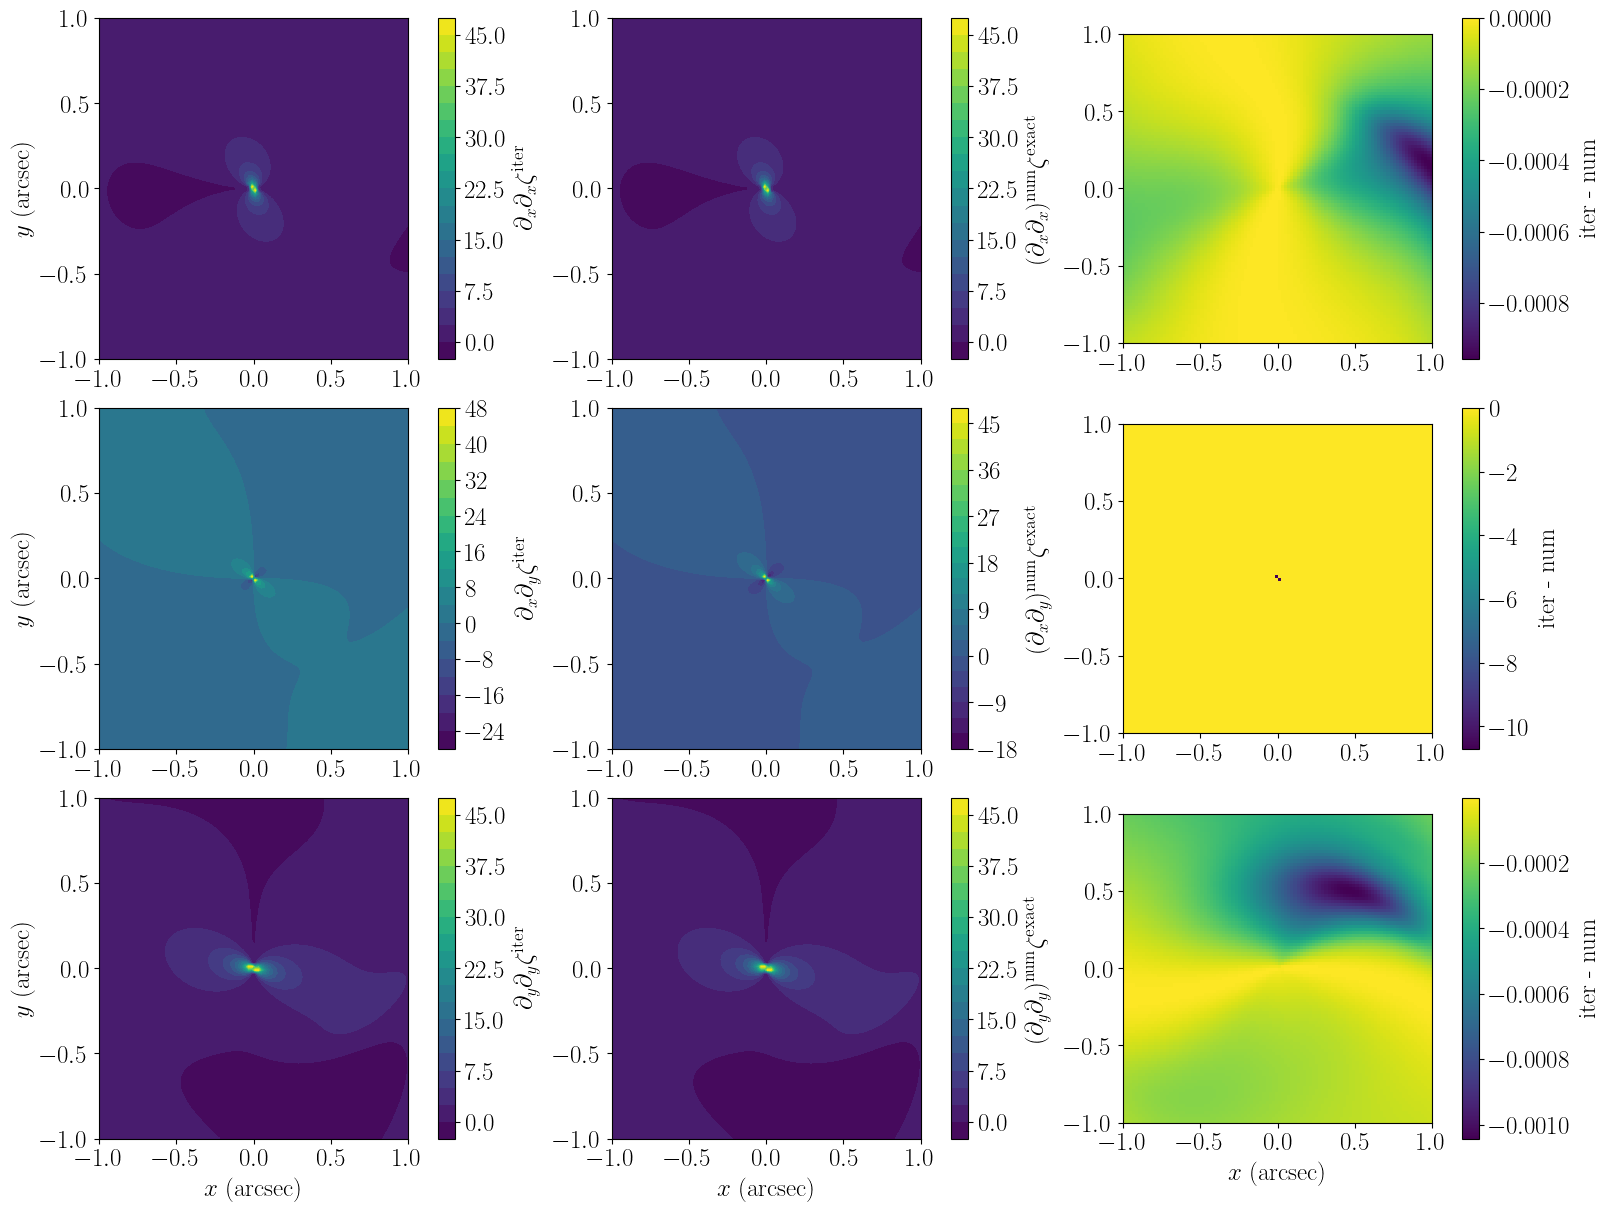

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(16, 4*3), layout="constrained")

hessian_num = [zeta_xx_num, zeta_xy_num, zeta_yy_num]
labels = [[r'$\partial_x\partial_x\zeta^{\rm iter}$', r'$(\partial_x\partial_x)^{\rm num}\zeta^{\rm exact}$', r'iter - num'],
          [r'$\partial_x\partial_y\zeta^{\rm iter}$', r'$(\partial_x\partial_y)^{\rm num}\zeta^{\rm exact}$', r'iter - num'],
          [r'$\partial_y\partial_y\zeta^{\rm iter}$', r'$(\partial_y\partial_y)^{\rm num}\zeta^{\rm exact}$', r'iter - num']]

for i, zeta_ij in enumerate([zeta_xx, zeta_xy, zeta_yy]):

    zeta_ij_num = hessian_num[i]
    diff = zeta_ij - zeta_ij_num

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta_ij, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][0])

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, zeta_ij_num, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][1])

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=labels[i][2])

for i in range(3):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[2, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

# 3. Radial profile of the potential

We parameterise the potential as
$$
\psi(\theta) = \psi_0\left[1 + \left(\frac{\theta}{\theta_{\rm c}}\right)^s\right]^{\frac{3-\gamma}{s}}
$$
with
$$
\psi_0
\equiv
\frac{\theta_{\rm E}^2}{3-\gamma}
\left(\frac{\theta_{\rm c}}{\theta_{\rm E}}\right)^s
\left[1 + \left(\frac{\theta_{\rm E}}{\theta_{\rm c}}\right)^{s}\right]^{1-\frac{3-\gamma}{s}}
$$
ensuring that the Einstein radius is $\theta_{\rm E}$.

In [19]:
def potential_radial(theta, theta_E, theta_core, sharpness, outer_slope):
    """
    Axially symmetric cored power law potential.
    """
    
    power = (3 - outer_slope) / sharpness
    
    # normalisation to ensure that the Einstein radius is theta_E
    R = theta_core / theta_E
    psi0 = theta_E**2 / (3 - outer_slope) * R**sharpness * (1 + R**(-sharpness))**(1 - power)

    
    psi    = psi0 * (1 + (theta/theta_core)**sharpness)**power
    
    psi_t  = theta_E * (theta/theta_E)**(sharpness-1) * (
        (theta_core**sharpness + theta**sharpness)/(theta_core**sharpness + theta_E**sharpness))**(power - 1)
    
    psi_tt = (sharpness - 1 + (3 - outer_slope - sharpness)
              * theta**sharpness / (theta_core**sharpness + theta**sharpness)) * psi_t / theta

    
    return psi, psi_t, psi_tt

Check consistency of the derivatives

/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_60380/2415491580.py:13: RuntimeWarning: invalid value encountered in power
  psi    = psi0 * (1 + (theta/theta_core)**sharpness)**power
/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_60380/2415491580.py:15: RuntimeWarning: invalid value encountered in power
  psi_t  = theta_E * (theta/theta_E)**(sharpness-1) * (
/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_60380/2415491580.py:16: RuntimeWarning: invalid value encountered in power
  (theta_core**sharpness + theta**sharpness)/(theta_core**sharpness + theta_E**sharpness))**(power - 1)
/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_60380/2415491580.py:19: RuntimeWarning: invalid value encountered in power
  * theta**sharpness / (theta_core**sharpness + theta**sharpness)) * psi_t / theta


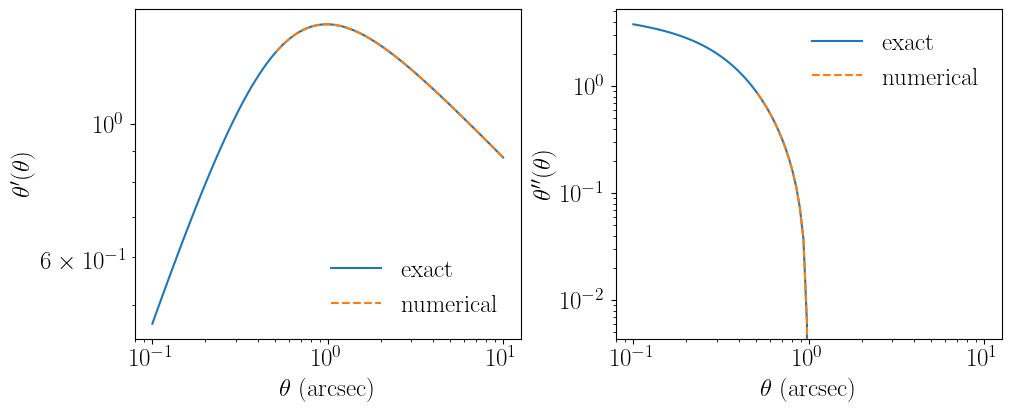

In [20]:
params_radial = {'theta_E': 1.43, 'theta_core': 0.56, 'sharpness': 1.86, 'outer_slope': 2.3}

zeta = np.logspace(-1, 1, 100)
psi, psi_z, psi_zz = potential_radial(zeta, **params_radial)

# compute psi_z numerically
func = lambda zeta: potential_radial(zeta, **params_radial)[0]
res = derivative(func, zeta)
psi_z_num = res.df

# compute psi_zz numerically
func = lambda zeta: potential_radial(zeta, **params_radial)[1]
res = derivative(func, zeta)
psi_zz_num = res.df

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')

ax=axes[0]
ax.loglog(zeta, psi_z, label='exact')
ax.loglog(zeta, psi_z_num, '--', label='numerical')
ax.set_xlabel(r'$\theta$ (arcsec)')
ax.set_ylabel(r"$\theta'(\theta)$")
ax.legend(frameon=False)

ax=axes[1]
ax.loglog(zeta, psi_zz, label='exact')
ax.loglog(zeta, psi_zz_num, '--', label='numerical')
ax.set_xlabel(r'$\theta$ (arcsec)')
ax.set_ylabel(r"$\theta''(\theta)$")
ax.legend(frameon=False)

plt.show();

Check normalisation
$$
\bar{\kappa}(<\theta) = \frac{1}{\theta} \frac{{\rm d}\psi}{{\rm d}\theta}
$$
and we must have $\bar{\kappa}(<\theta_{\rm E})=1$

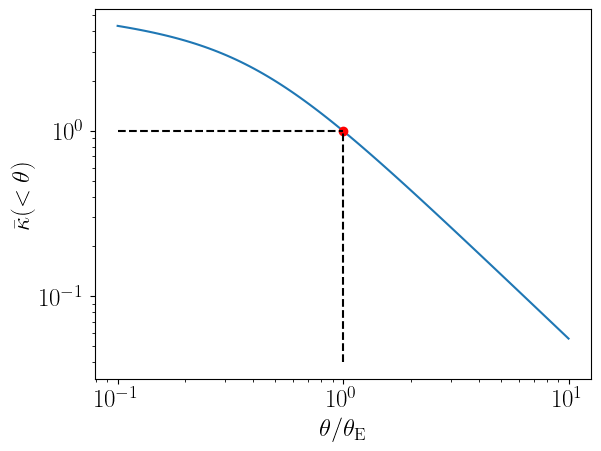

In [21]:
params_radial = {'theta_E': 1.43, 'theta_core': 0.56, 'sharpness': 1.86, 'outer_slope': 2.3}

theta = np.logspace(-1,  1, 100) * params_radial['theta_E']
psi, psi_z, psi_zz = potential_radial(theta, **params_radial)

plt.loglog(theta/params_radial['theta_E'], psi_z/theta)
plt.loglog([1], [1], 'ro')
plt.loglog([1e-1, 1], [1, 1], 'k--')
plt.loglog([1, 1], [4e-2, 1], 'k--')
plt.xlabel(r'$\theta/\theta_{\rm E}$')
plt.ylabel(r'$\bar{\kappa}(<\theta)$')
plt.show()

# 4. Combining radial profile and elliptical fields

In [81]:
params_ellipticity = {'e_inf': 0 , 'e_0': 0.3, 'Dzeta_e': 1}
params_pointing_angle = {'phi_0': 0.87, 'Dphi': 0.5, 'zeta_0': 0, 'Dzeta_phi': 1}
params_centre = {'drift_x': -0.02, 'drift_y': -0.03}
params_ellipses = params_ellipticity | params_pointing_angle | params_centre

params_radial = {'theta_E': 1.43, 'theta_core': 0.56, 'sharpness': 1.54, 'outer_slope': 2.3}

In [82]:
def lensing_fields(x, y):

    zeta, (zeta_x, zeta_y), (zeta_xx, zeta_xy, zeta_yy) = get_elliptical_radius(X, Y, N_iter=3, **params_ellipses)
    psi, psi_t, psi_tt = potential_radial(zeta, **params_radial)

    # displacement
    alpha_x = psi_t * zeta_x
    alpha_y = psi_t * zeta_y

    # Hessian
    H_xx = psi_tt * zeta_x * zeta_x + psi_t * zeta_xx
    H_xy = psi_tt * zeta_x * zeta_y + psi_t * zeta_xy
    H_yy = psi_tt * zeta_y * zeta_y + psi_t * zeta_yy

    return psi, (alpha_x, alpha_y), (H_xx, H_xy, H_yy)

Plot the various fields

In [83]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

start = time.perf_counter()
psi, (alpha_x, alpha_y), (H_xx, H_xy, H_yy) = lensing_fields(X * params_radial['theta_E'], Y * params_radial['theta_E'])
end = time.perf_counter()
timing = 1000 * (end - start) # ms
print("Time for the whole grid = {} ms".format(timing))

Time for the whole grid = 14.707210939377546 ms


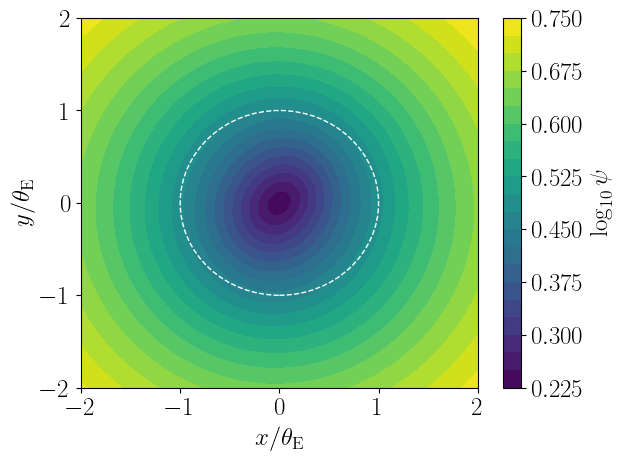

In [84]:
fig, ax = plt.subplots()

contours = ax.contourf(X, Y, np.log10(psi), levels=20)
fig.colorbar(contours, ax=ax, label=r'$\log_{10}\psi$')

# Einstein radius for indication
ax.add_artist(Circle(xy=(0, 0), radius=1, facecolor="none", edgecolor='white', ls='--'))

# Core ellipse
#x0 = drift_x * theta_core
#y0 = drift_y * theta_core
#q = (1 + e**2)**0.5 - e
#a = theta_core / q**0.5
#b = theta_core * q**0.5
#ellipse_core = Ellipse(
#    xy=(x0, y0),
#    width=2*a,
#    height=2*b,
#   angle=phi * 180 / np.pi,
#    facecolor="none",
#    edgecolor='orange'
#    )
#ax.add_artist(ellipse_core)

ax.set_xlabel(r"$x/\theta_{\rm E}$")
ax.set_ylabel(r"$y/\theta_{\rm E}$")
plt.show()

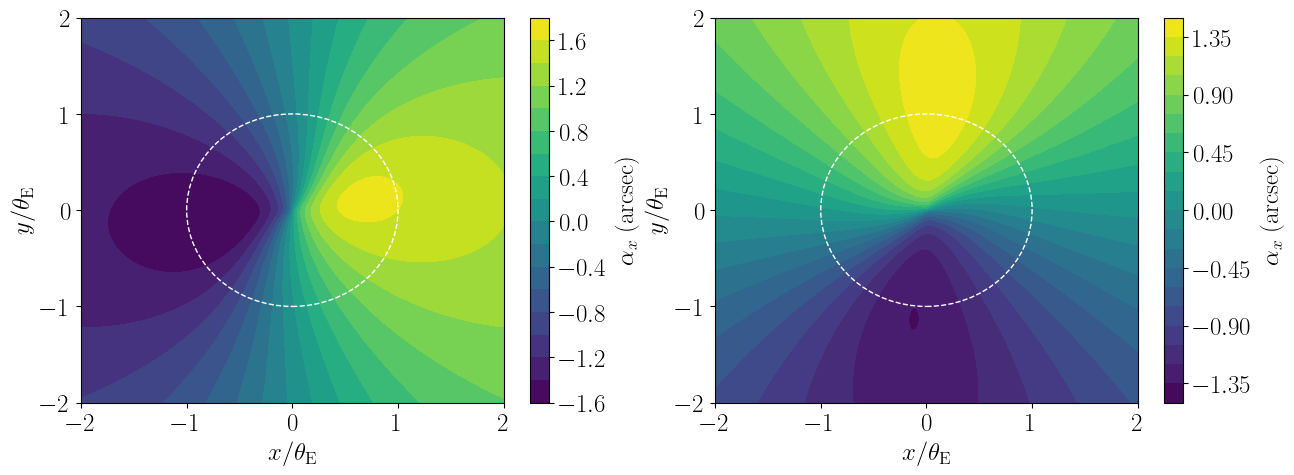

In [79]:
# plot alpha_x and alpha_x
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, alpha_i in enumerate([alpha_x, alpha_y]):
    
    ax = axes[i]
    contours = ax.contourf(X, Y, alpha_i, levels=20)
    ax.set_xlabel(r"$x/\theta_{\rm E}$")
    ax.set_ylabel(r"$y/\theta_{\rm E}$")
    fig.colorbar(contours, ax=ax, label=r'$\alpha_x$ (arcsec)')
    ax.add_artist(Circle(xy=(0, 0), radius=1, facecolor="none", edgecolor='white', ls='--'))

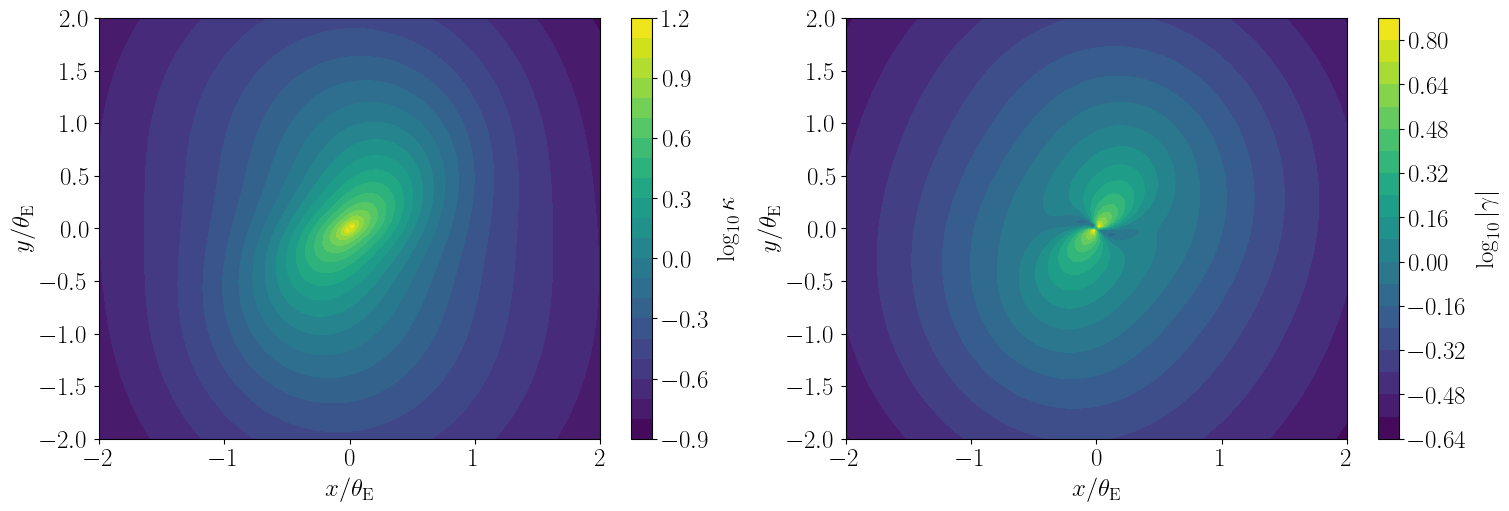

In [80]:
kappa = (H_xx + H_yy) / 2
gamma1 = H_xx - kappa
gamma2 = H_xy
gamma = (gamma1**2 + gamma2**2)**0.5

fig, axes = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')

ax = axes[0]
contours = ax.contourf(X, Y, np.log10(kappa), levels=20)
ax.set_xlabel(r"$x/\theta_{\rm E}$")
ax.set_ylabel(r"$y/\theta_{\rm E}$")
fig.colorbar(contours, ax=ax, label=r'$\log_{10}\kappa$')

ax = axes[1]
contours = ax.contourf(X, Y, np.log10(gamma), levels=20)
ax.set_xlabel(r"$x/\theta_{\rm E}$")
ax.set_ylabel(r"$y/\theta_{\rm E}$")
fig.colorbar(contours, ax=ax, label=r'$\log_{10}|\gamma|$')

plt.show();

TypeError: unsupported operand type(s) for -: 'function' and 'float'

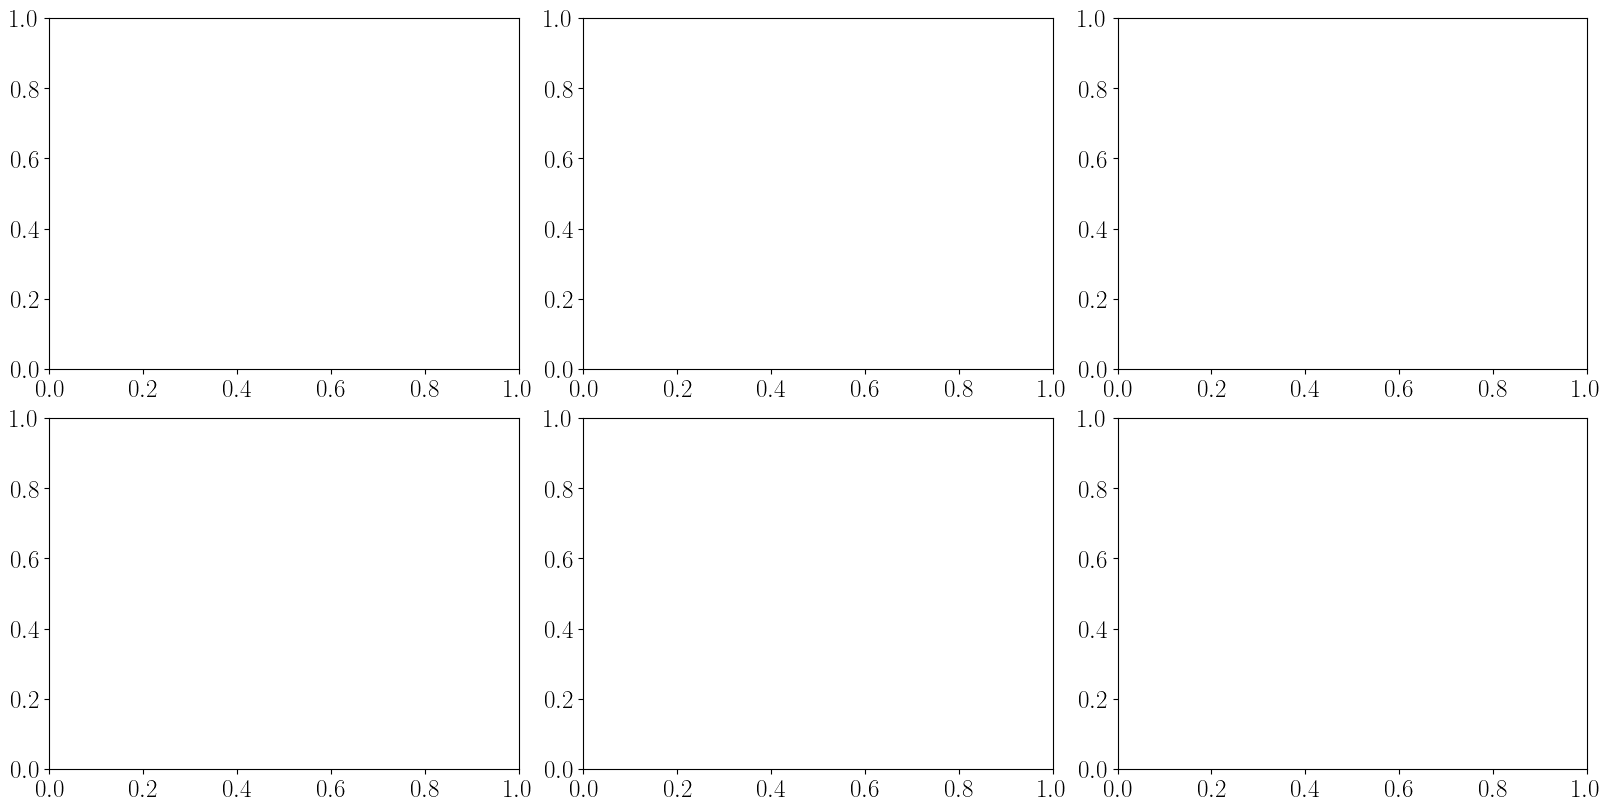

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(16, 4*2), layout="constrained")

grad_zeta_num = [zeta_x_num, zeta_y_num]
labels = [[r'$\partial_x\zeta^{\rm iter}$', r'$\partial_x\zeta^{\rm num}$', r'iter - num'],
          [r'$\partial_y\zeta^{\rm iter}$', r'$\partial_y\zeta^{\rm num}$', r'iter - num']]

for i, zeta_i in enumerate([zeta_x, zeta_y]):

    zeta_i_num = grad_zeta_num[i]
    diff = zeta_i - zeta_i_num

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta_i, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][0])

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, zeta_i_num, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][1])

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=labels[i][2])

for i in range(2):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[1, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

In [103]:
def ellipse_matrix(e1, e2):
    """
    Matrix involved in the equation of an ellipse with ellipticity (e1, e2)
    """
    
    E_xx = (1 + e1**2 + e2**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e1**2 + e2**2)**0.5 + e1

    return E_xx, E_xy, E_yx, E_yy


def elliptical_radius_constant(x, y, e1, e2, drift_x, drift_y):
    """
    Calculates the elliptical radius zeta of the ellipse containing (x, y),
    assuming constant ellipticity (e1, e2) and a linear drift of the centre
    with radius:
    x0 = drift_x * zeta
    y0 = drift_y * zeta
    """

    # ellipse matrix and inner product

    E_xx, E_xy, E_yx, E_yy = ellipse_matrix(e1, e2)

    
    def EV(vx, vy):
        
        "Matrix product of E with vector (vx, vy)"
        
        EV_x = E_xx * vx + E_xy * vy
        EV_y = E_yx * vx + E_yy * vy
        
        return EV_x, EV_y


    # main quantities
    
    ED_x, ED_y = EV(drift_x, drift_y)
    EX_x, EX_y = EV(x, y)

    DED = drift_x * ED_x + drift_y * ED_y
    DEX = drift_x * EX_x + drift_y * EX_y
    XEX = x * EX_x + y * EX_y

    
    # Final expression of the elliptical radius
    
    zeta = (((1 - DED) * XEX + DEX**2)**0.5 - DEX) / (1 - DED)

    
    return zeta

In [5]:
def elliptical_radius(x, y, method='iterative', N_iter=10):
    """
    Find the elliptical radius numerically or iteratively. 
    """
    
    if method=='iterative':

        zeta = (x**2 + y**2)**0.5 # first guess
        
        for i in range(N_iter):
    
            e, phi, drift_x, drift_y = ellipse_fields(zeta, **params)
    
            e1 = e * np.cos(2*phi)
            e2 = e * np.sin(2*phi)
        
            zeta = elliptical_radius_constant(x, y, e1, e2, drift_x, drift_y)

    
    elif method=='numerical': # Something does not work with this option when x, y are a mesh

        def zeta_equation(zeta):
            
            e, phi, drift_x, drift_y = ellipse_fields(zeta, **params)
            e1 = e * np.cos(2*phi)
            e2 = e * np.sin(2*phi)
            E_xx, E_xy, E_yx, E_yy = ellipse_matrix(e1, e2)
            x1 = x - drift_x * zeta
            y1 = y - drift_y * zeta
            EX1_x = E_xx * x1 + E_xy * y1
            EX1_y = E_yx * x1 + E_yy * y1
            X1EX1 = x1 * EX1_x + y1 * EX1_y

            return zeta**2 - X1EX1

        zeta0 = (x**2 + y**2)**0.5 # first guess
        print(zeta0.shape)
        zeta = fsolve(zeta_equation, zeta0)

    else:
        raise ValueError("method must be 'iterative' or 'numerical'.")

    
    return zeta

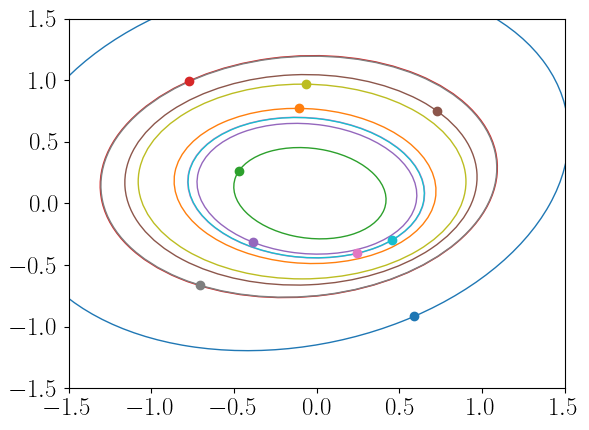

In [7]:
# generate a set of N random points in [-1, 1]^2
N = 10
x = 2 * np.random.random_sample(N) - 1
y = 2 * np.random.random_sample(N) - 1

# get the corresponding elliptical radii
zetas = elliptical_radius(x, y, method='iterative', N_iter=10)
#zetas = elliptical_radius(x, y, method='numerical')

# plot the points and the ellipses
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots()

for i, zeta in enumerate(zetas):

    x0 = params['drift_x'] * zeta
    y0 = params['drift_y'] * zeta
    e = ellipticity(zeta, **params_ellipticity)
    phi = pointing_angle(zeta, **params_pointing_angle)
    q = (1 + e**2)**0.5 - e
    a = zeta / q**0.5
    b = zeta * q**0.5

    colour = colours[i% len(colours)]
    
    ellipse = Ellipse(
    xy=(x0, y0),
    width=2*a,
    height=2*b,
    angle=phi * 180 / np.pi,
    facecolor="none",
    edgecolor=colour
    )
    
    ax.plot(x[i], y[i], 'o', color=colour)
    ax.add_artist(ellipse)

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.show()

To do: field of difference between actual zeta and iterative zeta + evaluation of the timing

In [8]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)


zeta_exact = elliptical_radius(X, Y, method='iterative', N_iter=100)
#zeta_exact = elliptical_radius(X, Y, method='numerical')


N_iters = [3, 5, 10]
zeta_iterative = []

for N_iter in N_iters:
    
    zeta = elliptical_radius(X, Y, method='iterative', N_iter=N_iter)
    zeta_iterative.append(zeta)

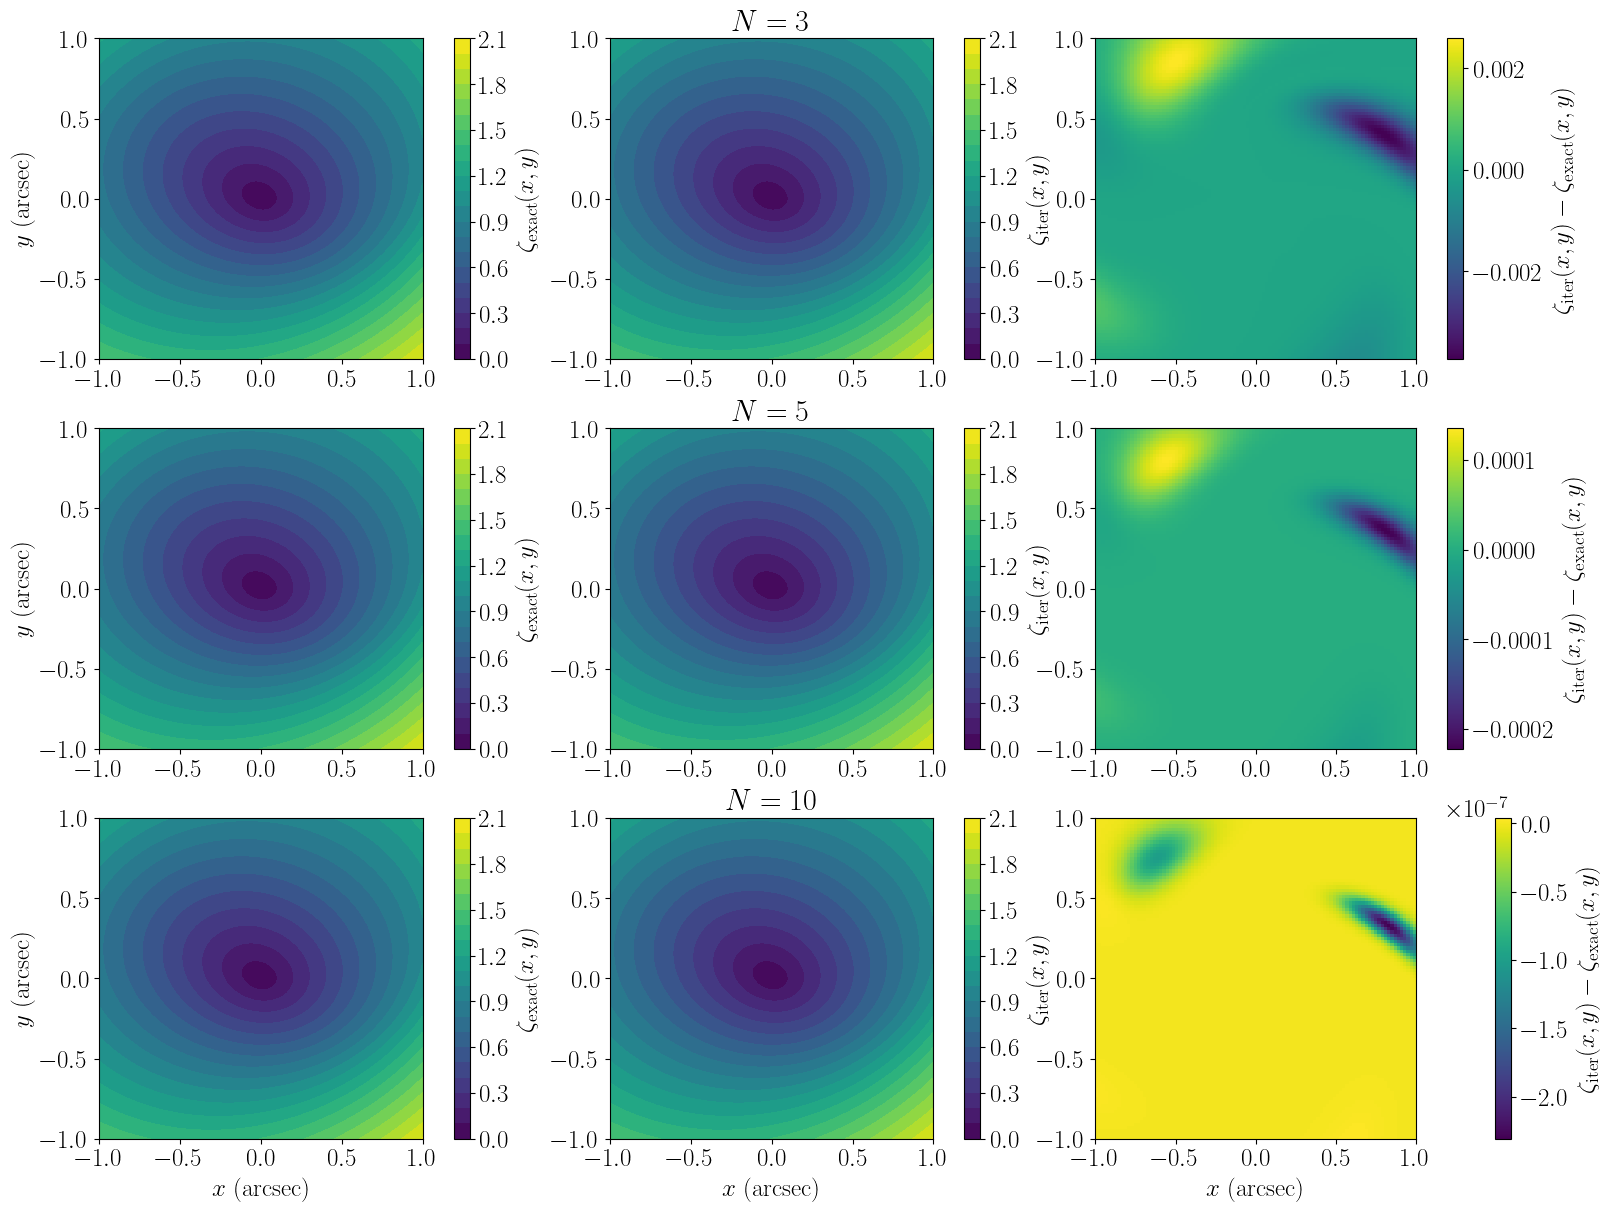

In [9]:
fig, axes = plt.subplots(len(N_iters), 3, figsize=(16, 4*len(N_iters)), layout="constrained")

for i, N_iter in enumerate(N_iters):

    zeta = zeta_iterative[i]
    diff = zeta - zeta_exact

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta_exact, levels=20)
    fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm exact}(x, y)$')

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, zeta, levels=20)
    fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm iter}(x, y)$')
    ax.set_title(r"$N = {}$".format(N_iter))

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=r'$\zeta_{\rm iter}(x, y) - \zeta_{\rm exact}(x, y)$')

for i in range(len(N_iters)):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[len(N_iters)-1, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

In [10]:
start = time.perf_counter()
elliptical_radius(X, Y, method='iterative', N_iter=1)
end = time.perf_counter()
print("Time if 1 iteration = ", end - start)

start = time.perf_counter()
elliptical_radius(X, Y, method='iterative', N_iter=10)
end = time.perf_counter()
print("Time if 10 iterations = ", end - start)

start = time.perf_counter()
elliptical_radius(X, Y, method='iterative', N_iter=100)
end = time.perf_counter()
print("Time if 100 iterations = ", end - start)

Time if 1 iteration =  0.0026328458916395903
Time if 10 iterations =  0.0050636951345950365
Time if 100 iterations =  0.0470811459235847


# 3. A more flexible code (but is it efficient?)

Ellipse fields with the central position

In [23]:
params_ellipticity = {'e_inf': 0.1 , 'e_0': 0.3, 'Dzeta_e': 2}
params_pointing_angle = {'phi_0': 0.1, 'Dphi': 20 * np.pi / 180, 'zeta_0': 1, 'Dzeta_phi': 0.5}
params_drift = {'drift_x': -0.1, 'drift_y': 0.2}
params = params_ellipticity | params_pointing_angle | params_drift

In [24]:
def ellipse_fields(zeta, e_inf, e_0, Dzeta_e, phi_0, Dphi, zeta_0, Dzeta_phi, drift_x, drift_y):

    e = e_inf + (e_0 - e_inf) * np.exp(-zeta / Dzeta_e)
    phi = phi_0 + 4 * Dphi / np.pi * np.arctan((zeta - zeta_0) / Dzeta_phi)
    x0 = drift_x * zeta
    y0 = drift_y * zeta

    return e, phi, x0, y0

In [25]:
def ellipse_matrix(e1, e2):
    """
    Matrix involved in the equation of an ellipse with ellipticity (e1, e2)
    """
    
    E_xx = (1 + e1**2 + e2**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e1**2 + e2**2)**0.5 + e1

    return E_xx, E_xy, E_yx, E_yy


def elliptical_radius(x, y, N_iter=10):
    """
    Find the elliptical radius iteratively. 
    """

    zeta = (x**2 + y**2)**0.5 # first guess

    
    for i in range(N_iter):
    
        e, phi, x0, y0 = ellipse_fields(zeta, **params)
    
        e1 = e * np.cos(2*phi)
        e2 = e * np.sin(2*phi)
        E_xx, E_xy, E_yx, E_yy = ellipse_matrix(e1, e2)
        
        DX_x, DX_y = x - x0, y - y0
        EDX_x = E_xx * DX_x + E_xy * DX_y
        EDX_y = E_yx * DX_x + E_yy * DX_y
        DXEDX = DX_x * EDX_x + DX_y * EDX_y
        
        zeta = DXEDX**0.5

    return zeta

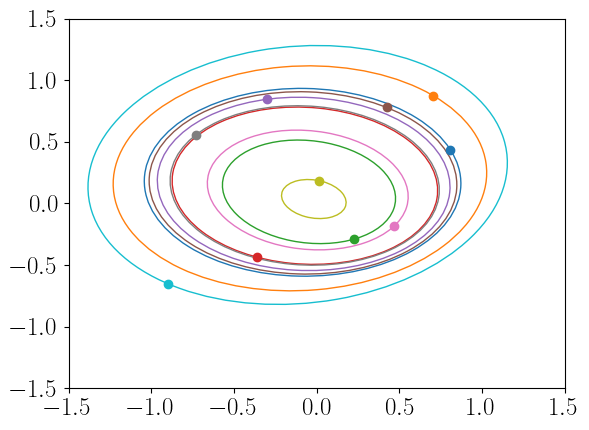

In [27]:
# generate a set of N random points in [-1, 1]^2
N = 10
x = 2 * np.random.random_sample(N) - 1
y = 2 * np.random.random_sample(N) - 1

# get the corresponding elliptical radii
zetas = elliptical_radius(x, y, N_iter=10)

# plot the points and the ellipses
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots()

for i, zeta in enumerate(zetas):

    e, phi, x0, y0 = ellipse_fields(zeta, **params)
    q = (1 + e**2)**0.5 - e
    a = zeta / q**0.5
    b = zeta * q**0.5

    colour = colours[i% len(colours)]
    
    ellipse = Ellipse(
    xy=(x0, y0),
    width=2*a,
    height=2*b,
    angle=phi * 180 / np.pi,
    facecolor="none",
    edgecolor=colour
    )
    
    ax.plot(x[i], y[i], 'o', color=colour)
    ax.add_artist(ellipse)

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.show()

In [35]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)


zeta_exact = elliptical_radius(X, Y, N_iter=100)
#zeta_exact = elliptical_radius(X, Y, method='numerical')


N_iters = [3, 5, 15]
zeta_iterative = []

for N_iter in N_iters:
    
    zeta = elliptical_radius(X, Y, N_iter=N_iter)
    zeta_iterative.append(zeta)

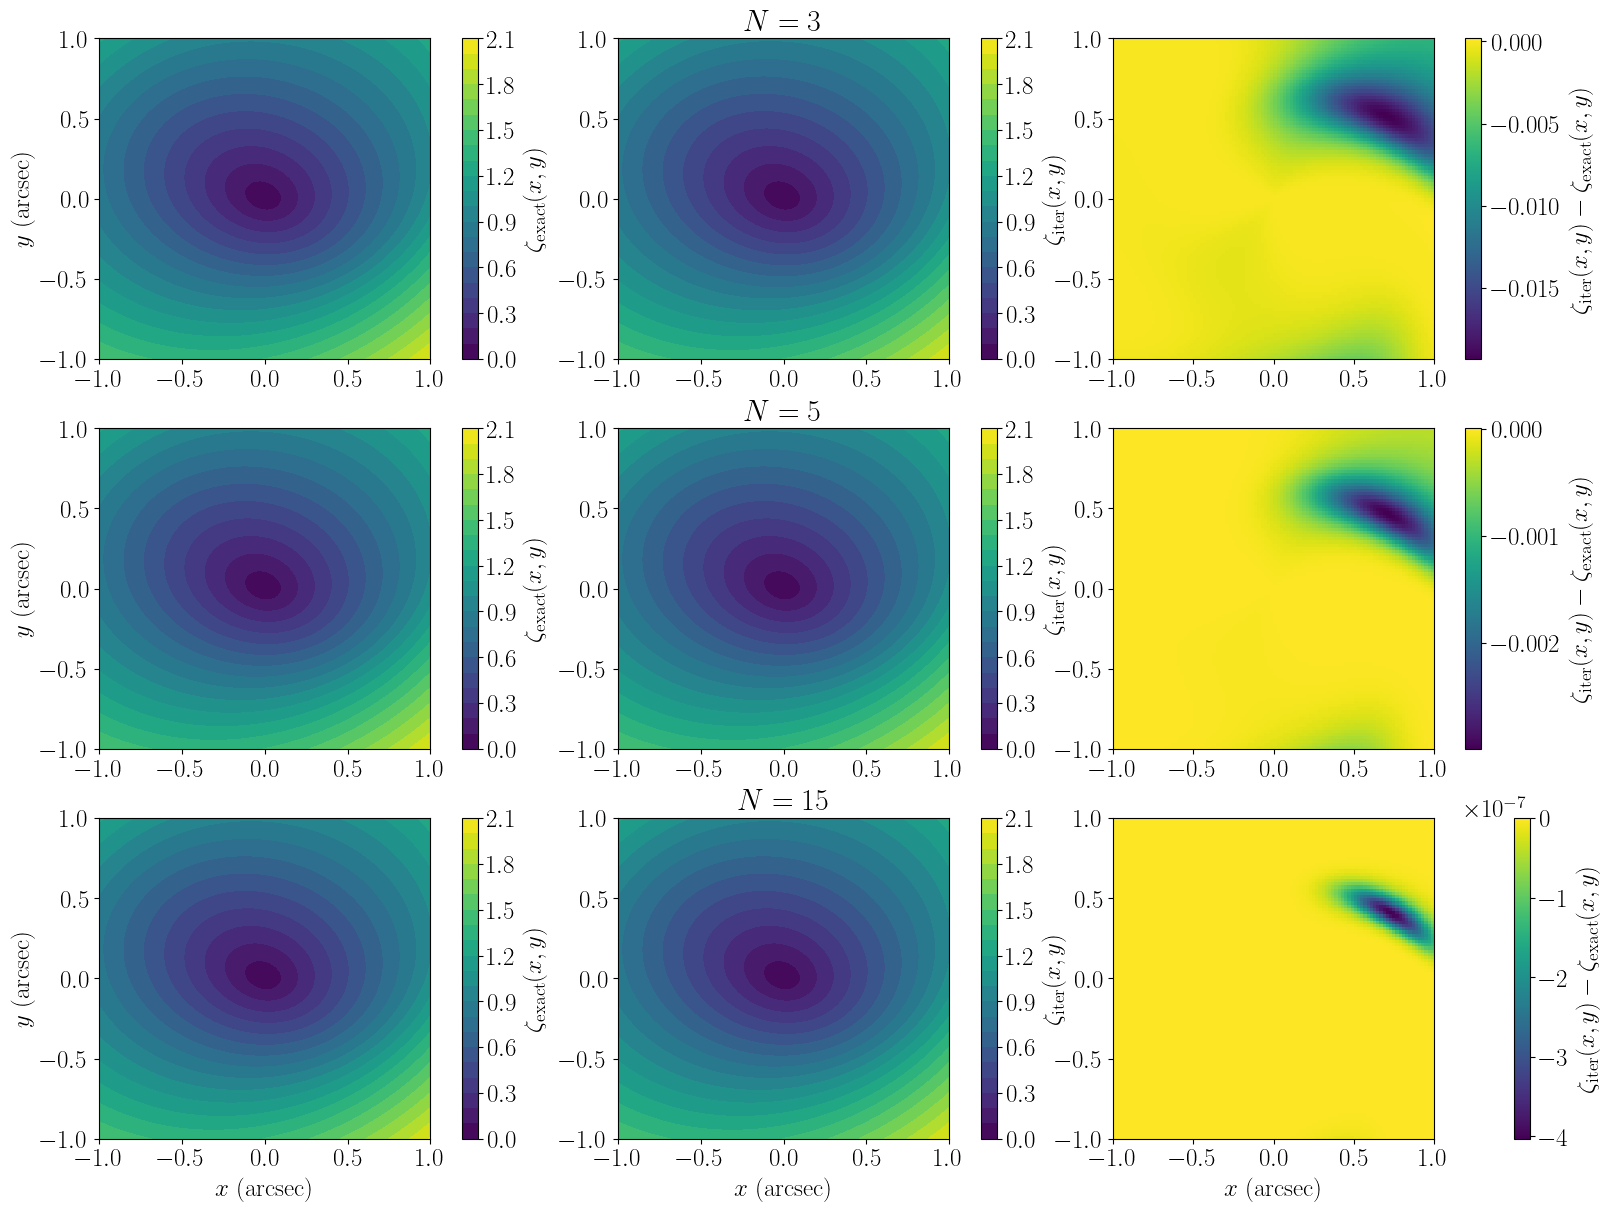

In [36]:
fig, axes = plt.subplots(len(N_iters), 3, figsize=(16, 4*len(N_iters)), layout="constrained")

for i, N_iter in enumerate(N_iters):

    zeta = zeta_iterative[i]
    diff = zeta - zeta_exact

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta_exact, levels=20)
    fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm exact}(x, y)$')

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, zeta, levels=20)
    fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm iter}(x, y)$')
    ax.set_title(r"$N = {}$".format(N_iter))

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=r'$\zeta_{\rm iter}(x, y) - \zeta_{\rm exact}(x, y)$')

for i in range(len(N_iters)):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[len(N_iters)-1, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

In [42]:
start = time.perf_counter()
elliptical_radius(X, Y, N_iter=1)
end = time.perf_counter()
print("Time if 1 iteration = ", end - start)

start = time.perf_counter()
elliptical_radius(X, Y, N_iter=15)
end = time.perf_counter()
print("Time if 15 iterations = ", end - start)

start = time.perf_counter()
elliptical_radius(X, Y, N_iter=100)
end = time.perf_counter()
print("Time if 100 iterations = ", end - start)

Time if 1 iteration =  0.00225186999887228
Time if 15 iterations =  0.005919973133131862
Time if 100 iterations =  0.03693120810203254


Not as efficient

# 4. Using the gradients 

In [128]:
params_ellipticity = {'e_inf': 0.1 , 'e_0': 0.3, 'Dzeta_e': 2}
params_pointing_angle = {'phi_0': 0.1, 'Dphi': 20 * np.pi / 180, 'zeta_0': 1, 'Dzeta_phi': 0.5}
params_drift = {'drift_x': -0.1, 'drift_y': 0.2}
params = params_ellipticity | params_pointing_angle | params_drift

In [129]:
def ellipse_fields(zeta, e_inf, e_0, Dzeta_e, phi_0, Dphi, zeta_0, Dzeta_phi, drift_x, drift_y):
    """
    Calculates the ellipticity, pointing angle and central position of the ellipse
    with elliptical radius zeta, as well as their derivatives with respect to zeta.
    """

    e      = e_inf + (e_0 - e_inf) * np.exp(-zeta / Dzeta_e)
    e_zeta = - (e_0 - e_inf) / Dzeta_e * np.exp(-zeta / Dzeta_e)
    
    phi      = phi_0 + 4 * Dphi / np.pi * np.arctan((zeta - zeta_0) / Dzeta_phi)
    phi_zeta = 4 * Dphi / np.pi / Dzeta_phi / (1 + (zeta - zeta_0)**2 / Dzeta_phi**2)
    
    x0 = drift_x * zeta
    x0_zeta = drift_x
    
    y0 = drift_y * zeta
    y0_zeta = drift_y

    return (e, phi, x0, y0), (e_zeta, phi_zeta, x0_zeta, y0_zeta)

In [167]:
def elliptical_radius_function(x, y, zeta, **params):
    """
    Define F such that zeta = F(x, y; zeta)
    This returns F and its derivative with respect to zeta and x and y
    """

    # properties of the ellipse at zeta
    
    (e, phi, x0, y0), (e_zeta, phi_zeta, x0_zeta, y0_zeta) = ellipse_fields(zeta, **params)

    
    # calculate F
    
    x1 = x - x0
    y1 = y - y0

    e1 = e * np.cos(2*phi)
    e2 = e * np.sin(2*phi)
    
    E_xx = (1 + e**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e**2)**0.5 + e1

    EX1_x = E_xx * x1 + E_xy * y1
    EX1_y = E_yx * x1 + E_yy * y1
        
    F2 = EX1_x * x1 + EX1_y * y1
    F = F2**0.5

    
    # partial derivative of F with respect to zeta

    E_xx_e = e / (1 + e**2)**0.5 - np.cos(2*phi)
    E_xy_e = - np.sin(2*phi)
    E_yx_e = E_xy_e
    E_yy_e = e / (1 + e**2)**0.5 + np.cos(2*phi)

    E_xx_phi = 2 * e2
    E_xy_phi = - 2 * e1
    E_yx_phi = E_xy_phi
    E_yy_phi = - 2 * e2

    E_xx_zeta = e_zeta * E_xx_e + phi_zeta * E_xx_phi
    E_xy_zeta = e_zeta * E_xy_e + phi_zeta * E_xy_phi
    E_yx_zeta = E_xy_zeta
    E_yy_zeta = e_zeta * E_yy_e + phi_zeta * E_yy_phi

    X0pEX1 = x0_zeta * EX1_x + y0_zeta * EX1_y
    X1EpX1 = x1 * (E_xx_zeta * x1 + E_xy_zeta * y1) + y1 * (E_yx_zeta * x1 + E_yy_zeta * y1)
    
    F2_zeta = - 2 * X0pEX1 + X1EpX1
    F_zeta = F2_zeta / 2 / F
    
    # partial derivatives of F with respect to x and y
    F_x = EX1_x / F
    F_y = EX1_y / F
    
    return F, F_zeta, (F_x, F_y)

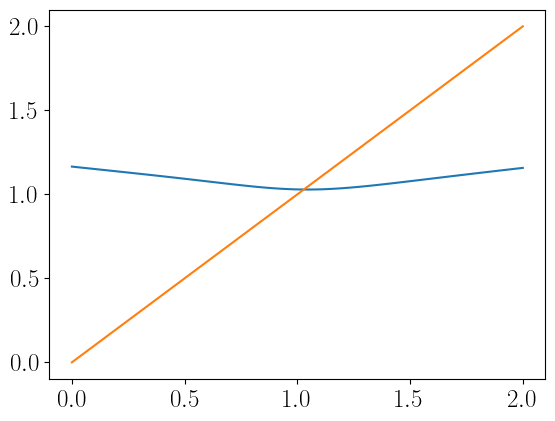

In [180]:
x, y = 1, 0.5
zeta = np.linspace(0, 2, 100)
F, F_zeta, _ = elliptical_radius_function(x, y, zeta, **params)

plt.plot(zeta, F)
plt.plot([0, 2], [0, 2])
plt.show()

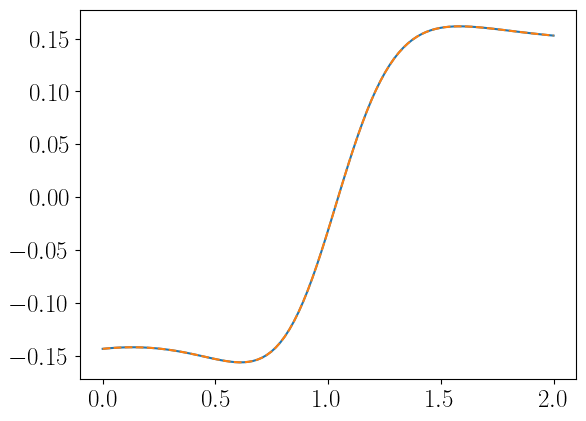

In [181]:
F = lambda zeta: elliptical_radius_function(x, y, zeta, **params)[0]
res = derivative(F, zeta)
F_prime_num = res.df

plt.plot(zeta, F_zeta)
plt.plot(zeta, F_prime_num, '--')
plt.show()

In [170]:
def get_elliptical_radius(x, y, N_iter=5, **params):
    """
    Iteratively solve zeta = F(x, zeta) for zeta.
    """
    
    zeta = (x**2 + y**2)**0.5 # first guess
    
    
    for i in range(N_iter):

        F, F_zeta, (F_x, F_y) = elliptical_radius_function(x, y, zeta, **params)
        #dzeta = (2 * F - 2 * F**0.5 * zeta) / (2 * F**0.5 - F_zeta)
        dzeta = (F - zeta) / (1 - F_zeta)
        zeta += dzeta

    # gradient of zeta
    zeta_x = F_x / (1 - F_zeta)
    zeta_y = F_y / (1 - F_zeta)
        
    return zeta, (zeta_x, zeta_y)

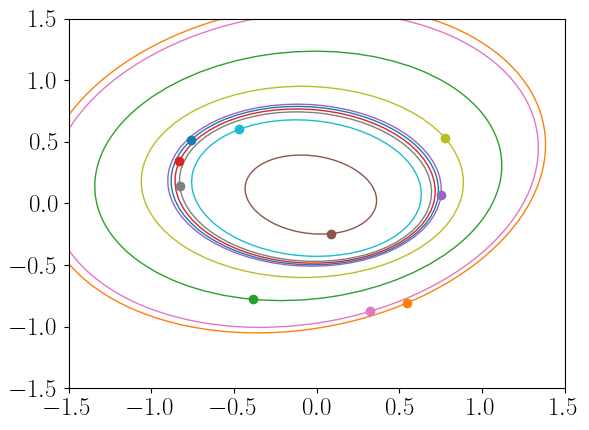

In [172]:
# generate a set of N random points in [-1, 1]^2
N = 10
x = 2 * np.random.random_sample(N) - 1
y = 2 * np.random.random_sample(N) - 1

# get the corresponding elliptical radii
zetas, _ = get_elliptical_radius(x, y, N_iter=3, **params)

# plot the points and the ellipses
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots()

for i, zeta in enumerate(zetas):

    (e, phi, x0, y0), (e_zeta, phi_zeta, x0_zeta, y0_zeta) = ellipse_fields(zeta, **params)
    q = (1 + e**2)**0.5 - e
    a = zeta / q**0.5
    b = zeta * q**0.5

    colour = colours[i% len(colours)]
    
    ellipse = Ellipse(
    xy=(x0, y0),
    width=2*a,
    height=2*b,
    angle=phi * 180 / np.pi,
    facecolor="none",
    edgecolor=colour
    )
    
    ax.plot(x[i], y[i], 'o', color=colour)
    ax.add_artist(ellipse)

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.show()

In [176]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)


zeta_exact, _ = get_elliptical_radius(X, Y, N_iter=10, **params)

N_iters = [1, 2, 3]
zeta_iterative = []


for N_iter in N_iters:
    
    zeta, _ = get_elliptical_radius(X, Y, N_iter=N_iter, **params)
    zeta_iterative.append(zeta)

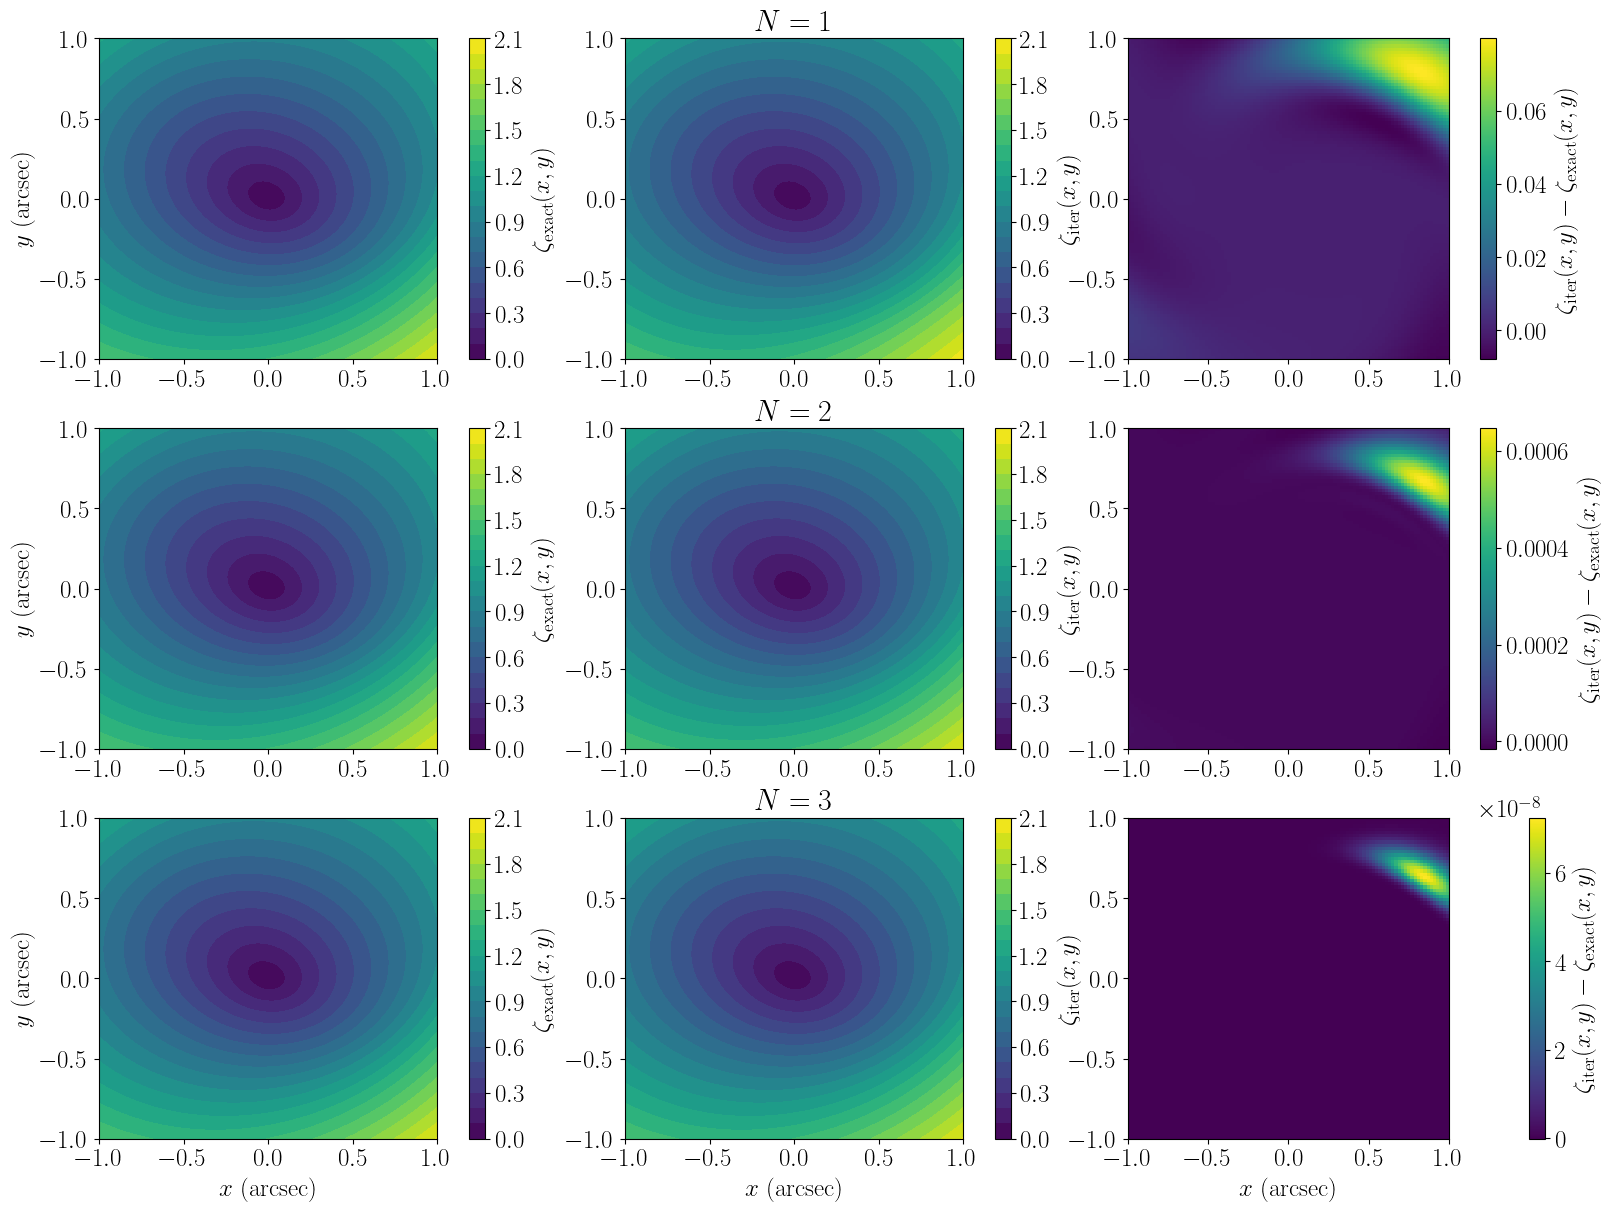

In [177]:
fig, axes = plt.subplots(len(N_iters), 3, figsize=(16, 4*len(N_iters)), layout="constrained")

for i, N_iter in enumerate(N_iters):

    zeta = zeta_iterative[i]
    diff = zeta - zeta_exact

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta_exact, levels=20)
    fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm exact}(x, y)$')

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, zeta, levels=20)
    fig.colorbar(contours, ax=ax, label=r'$\zeta_{\rm iter}(x, y)$')
    ax.set_title(r"$N = {}$".format(N_iter))

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=r'$\zeta_{\rm iter}(x, y) - \zeta_{\rm exact}(x, y)$')

for i in range(len(N_iters)):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[len(N_iters)-1, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();

In [215]:
start = time.perf_counter()
get_elliptical_radius(X, Y, N_iter=1, **params)
end = time.perf_counter()
print("Time if 1 iteration = ", end - start)

start = time.perf_counter()
get_elliptical_radius(X, Y, N_iter=3, **params)
end = time.perf_counter()
print("Time if 3 iterations = ", end - start)

start = time.perf_counter()
get_elliptical_radius(X, Y, N_iter=5, **params)
end = time.perf_counter()
print("Time if 5 iterations = ", end - start)

Time if 1 iteration =  0.0018401299603283405
Time if 3 iterations =  0.002706610132008791
Time if 5 iterations =  0.004709955072030425


This is extremely efficient!

Check that the gradients are working

In [234]:
zeta_x, zeta_y = get_elliptical_radius(X, Y, N_iter=4, **params)[1]

In [235]:
zeta_exact = lambda x, y: get_elliptical_radius(x, y, N_iter=10, **params)[0]
res = derivative(zeta_exact, X, args=(Y,))
zeta_x_num = res.df

zeta_exact = lambda y, x: get_elliptical_radius(x, y, N_iter=10, **params)[0]
res = derivative(zeta_exact, Y, args=(X,))
zeta_y_num = res.df

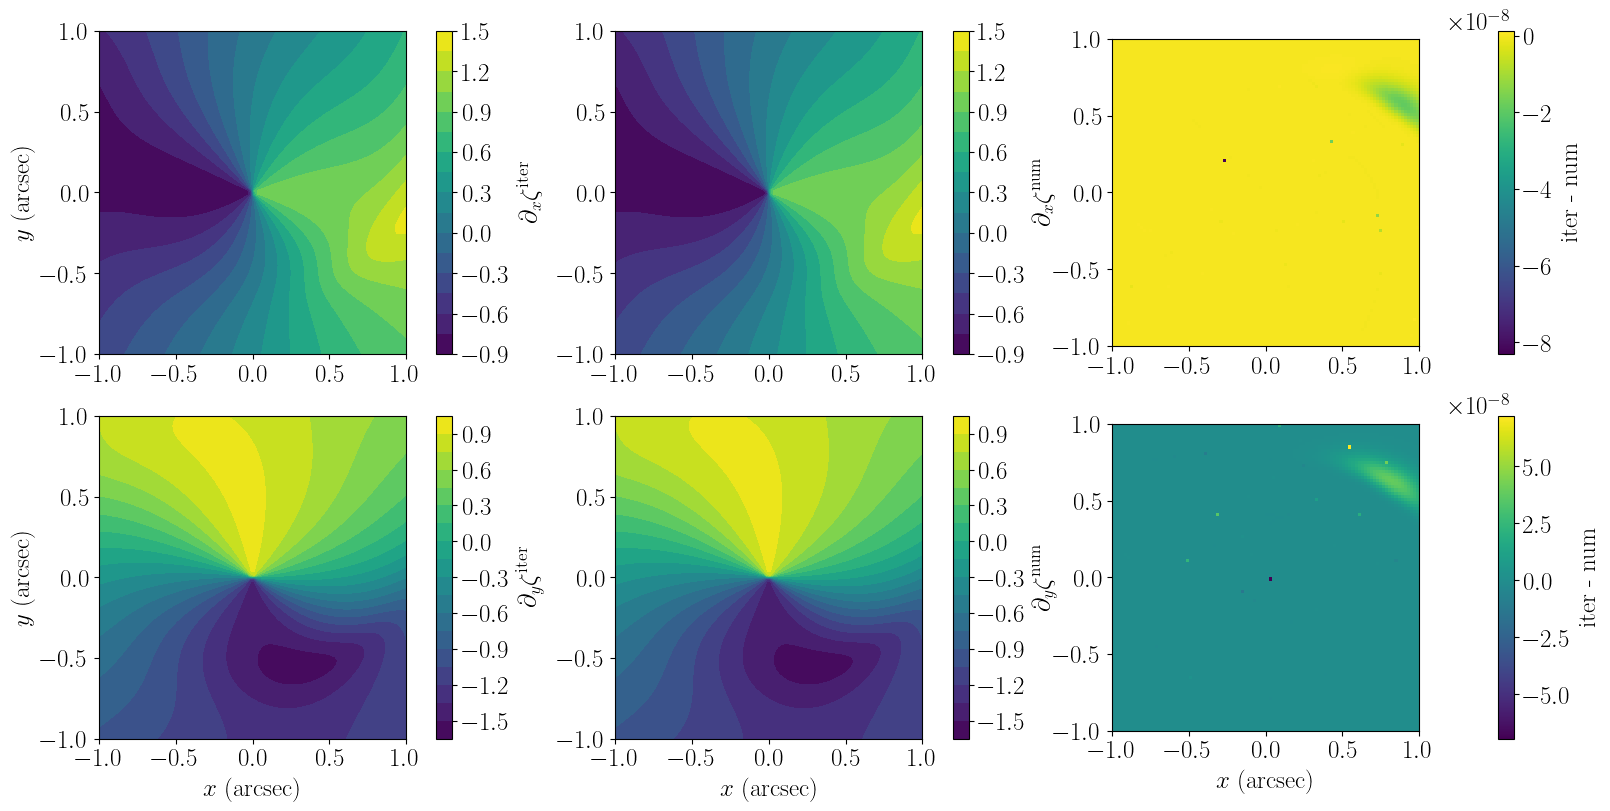

In [236]:
fig, axes = plt.subplots(2, 3, figsize=(16, 4*2), layout="constrained")

grad_zeta_num = [zeta_x_num, zeta_y_num]
labels = [[r'$\partial_x\zeta^{\rm iter}$', r'$\partial_x\zeta^{\rm num}$', r'iter - num'],
          [r'$\partial_y\zeta^{\rm iter}$', r'$\partial_y\zeta^{\rm num}$', r'iter - num']]

for i, zeta_i in enumerate([zeta_x, zeta_y]):

    zeta_i_num = grad_zeta_num[i]
    diff = zeta_i - zeta_i_num

    ax = axes[i, 0]
    contours = ax.contourf(X, Y, zeta_i, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][0])

    ax = axes[i, 1]
    contours = ax.contourf(X, Y, zeta_i_num, levels=20)
    fig.colorbar(contours, ax=ax, label=labels[i][1])

    ax = axes[i, 2]
    im = ax.imshow(diff, extent=(-1, 1, -1, 1))
    fig.colorbar(im, ax=ax, label=labels[i][2])

for i in range(2):
    axes[i, 0].set_ylabel(r"$y$ (arcsec)")
    
for j in range(3):
    axes[1, j].set_xlabel(r"$x$ (arcsec)")
        

plt.show();